### 独热编码，数据标准化，交叉验证



#### 导入数据

In [1]:
import pandas as pd
file_path = 'heart.csv'
data = pd.read_csv(file_path)

#### 打印表格数据的一些基础信息

In [2]:
print(f"前几行数据：\n{data.head()}")

前几行数据：
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [3]:
print(f"每列的数据类型：\n{data.info}")

每列的数据类型：
<bound method DataFrame.info of      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  H

In [4]:
print(f"数据的基础统计：\n{data.describe()}")

数据的基础统计：
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.125272   203.872549    0.233115  136.819172   
std      9.432617   16.993314    96.141390    0.423046   25.432057   
min     28.000000   90.000000    32.000000    0.000000   66.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  170.000000   408.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.877778      0.553377  
std      1.031693      0.497414  
min     -2.250000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      3.750000      1.000000  


#### 绘制直方图查看六个数值型变量的分布情况

<Axes: >

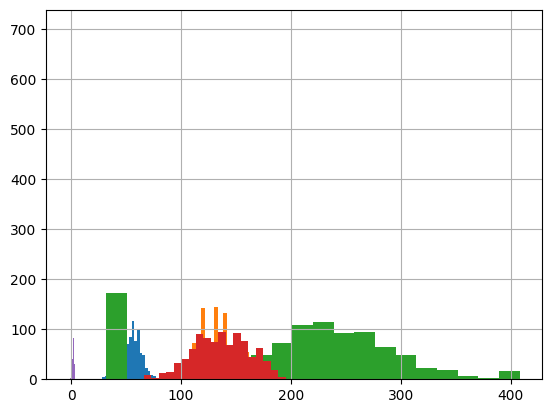

In [5]:
data["Age"].hist(bins=20)
data["RestingBP"].hist(bins=20)
data["Cholesterol"].hist(bins=20)
data["MaxHR"].hist(bins=20)
data["Oldpeak"].hist(bins=20) 
data["FastingBS"].hist(bins=20) 

#### 独热编码：为分类变量Sex，ChestPainType，RestingECG，ExerciseAngina，ST_Slope 创建独热编码,数据集更新为data2

In [6]:
data2=pd.get_dummies(data=data,columns=['Sex',"ChestPainType","RestingECG","ExerciseAngina","ST_Slope"])
print(data2.head())
columns_list = data2.columns.tolist()
print(f"所有列名：{columns_list}")


   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172      0.0             0   
1   49        160          180          0    156      1.0             1   
2   37        130          283          0     98      0.0             0   
3   48        138          214          0    108      1.5             1   
4   54        150          195          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LVH  RestingECG_Normal  RestingECG_ST  ExerciseAngina_

### 数据标准化和交叉验证:神经网络

#### 数据划分：X,Y矩阵

In [7]:
X=data2.drop("HeartDisease",axis=1).to_numpy()
Y=data2["HeartDisease"].to_numpy()
print(f"自变量矩阵形状：{X.shape}")
print(f"因变量矩阵形状：{Y.shape}")
print(f"X[0]:{X[0]}")
print(f"Y[0]:{Y[0]}")

自变量矩阵形状：(918, 20)
因变量矩阵形状：(918,)
X[0]:[40 140 289 0 172 0.0 False True False True False False False True False
 True False False False True]
Y[0]:0


#### 数据划分：80%训练集,20%测试集（只参与最后的测试）

In [8]:
from sklearn.model_selection import ShuffleSplit
seed=5
rs=ShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
tv_idx,test_idx=next(rs.split(X))
print(f"t+v（后续训练集和验证集）长度：{len(tv_idx)},测试集长度：{len(test_idx)}")
tvX,tvY=X[tv_idx],Y[tv_idx]
testX,testY=X[test_idx],Y[test_idx]
print(f"训练用数据：{tvX}\n{tvY}\n测试集：{testX}\n{testY}")

t+v（后续训练集和验证集）长度：734,测试集长度：184
训练用数据：[[55 135 250 ... False True False]
 [63 132 32 ... False False True]
 [67 145 32 ... False True False]
 ...
 [62 128 208 ... False False True]
 [35 120 308 ... False False True]
 [44 112 290 ... False False True]]
[0 0 1 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1
 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 1 1 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0
 0 0 1 1 1 0 0 1 0 1 0 1 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 1 1
 0 1 1 1 1 0 1 1 1 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 1 1 1 1 0 1 0
 0 1 1 1 1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 0 0 1 1 1 0 0 0 1 1 0 1 1 0 1 1 0 0 0 0 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1
 1 1 0 0 1 0 0 0 0 0 1 0 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 0
 0 0 1 1 0 1 1 1 0 1 0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 0 0 1 0 1 0 1
 1 0 0 1 0 0 1 0 1 0 1 0 1 1 0 0 1 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1
 0 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 0 1 0 0 1 1 1 0 0 1 0 0 1 1 1 0 1 1 0 1

#### 训练用数据划分：70%用于训练集，30%用于测试集

In [9]:
rs2=ShuffleSplit(n_splits=1, test_size=0.3, random_state=seed)
train_idx,val_idx=next(rs.split(tvX))
print(f"训练用数据条数：{len(train_idx)},验证集数据条数{len(val_idx)}")
tX,tY=tvX[train_idx],tvY[train_idx]
vX,vY=tvX[val_idx],tvY[val_idx]
print(f"训练用数据：{tX}\n{tY}\n验证用数据：{vX}\n{vY}")

训练用数据条数：587,验证集数据条数147
训练用数据：[[59 110 239 ... False True False]
 [41 130 214 ... False True False]
 [57 110 197 ... False False True]
 ...
 [63 139 217 ... False True False]
 [54 130 294 ... False True False]
 [45 130 237 ... False False True]]
[1 0 0 1 1 0 1 1 0 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 1
 0 1 1 1 0 0 0 1 0 0 1 0 0 1 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1
 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1 1 1 1 1 0 1 0 0 1 1 1 0 0 0
 1 1 1 0 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 1 1
 1 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1 0 0 0 1 1 0 0 0 0
 0 1 1 1 0 1 0 0 1 0 1 1 1 0 0 1 0 0 1 0 1 1 1 0 1 0 1 1 0 0 1 0 0 1 0 1 0
 1 0 0 1 1 0 0 0 0 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 0 1 0 1 0 0 0 0 1 1 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1
 0 1 1 1 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 1 1 0 1 0 0 1 1
 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 0 0 1 1 1 1 1 0 1 0 0 1 0
 0 1 

#### 数据的标准化

#### 下面将进行数据的标准化，我们用minmax方法将数据缩放到[0,1](注意这里并没有进行交叉验证）

In [11]:
from sklearn.preprocessing import  MinMaxScaler
def fitAndTransform(train,validation,cols_to_scale):
    minmax = MinMaxScaler()
    train_to_scale=train[cols_to_scale]
    validation_to_scale=validation[cols_to_scale]
    minmax.fit(train_to_scale)
    train_scaled=minmax.transform(train_to_scale)
    validation_scaled=minmax.transform(validation_to_scale)
    train_transformed=train.copy()
    validation_transformed=validation.copy()
    train_transformed[cols_to_scale]=train_scaled
    validation_transformed[cols_to_scale]=validation_scaled
    return train_transformed,validation_transformed,minmax
cols_to_scale=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
cols_all=['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
tX_df = pd.DataFrame(tX,columns=cols_all)
vX_df = pd.DataFrame(vX,columns=cols_all)
tsX_df,vsX_df,scalerX=fitAndTransform(tX_df,vX_df,cols_to_scale)
tsX,vsX,tsY,vsY=tsX_df.values,vsX_df.values,tY,vY
print(f"缩放后的训练集:\n{tsX_df}\n缩放后的验证集：{vsX_df}")
print(f"tsX:\n{tsX.shape}\nvsX:\n{vsX.shape}")


缩放后的训练集:
          Age  RestingBP  Cholesterol FastingBS     MaxHR   Oldpeak  Sex_F  \
0    0.625000     0.2500     0.550532         0  0.589147  0.575000  False   
1    0.250000     0.5000     0.484043         0  0.790698  0.708333  False   
2    0.583333     0.2500     0.438830         0  0.263566  0.375000  False   
3    0.291667     0.6250     0.680851         0  0.534884  0.708333  False   
4    0.854167     0.3125     0.000000         0  0.201550  0.375000  False   
..        ...        ...          ...       ...       ...       ...    ...   
582  0.750000     0.3750     0.385638         0  0.573643  0.441667  False   
583  0.520833     0.5000     0.452128         1  0.356589  0.708333  False   
584  0.708333     0.6125     0.492021         1  0.480620  0.575000  False   
585  0.520833     0.5000     0.696809         0  0.263566  0.375000   True   
586  0.333333     0.5000     0.545213         0  0.806202  0.375000   True   

     Sex_M ChestPainType_ASY ChestPainType_ATA ChestPa

#### 交叉验证






#### 由于数据量的限制，我们通过交叉验证来确保模型拥有良好的泛化能力，减少过拟合的风险，这样我们得到的训练和验证数据不再只有一份，而是多次抽取之后的多份数据

#### 我们使用随机分割交叉验证（Shuffle-Split Cross-Validation），K=10

In [12]:
def fitAndTransform(train, validation, cols_to_scale):
    minmax = MinMaxScaler()
    train_to_scale = train[cols_to_scale]
    validation_to_scale = validation[cols_to_scale]
    minmax.fit(train_to_scale)
    train_scaled = minmax.transform(train_to_scale)
    validation_scaled = minmax.transform(validation_to_scale)
    # 创建缩放后的数据集，并保持其他列不变
    train_transformed = train.copy()
    validation_transformed = validation.copy()
    train_transformed[cols_to_scale] = train_scaled
    validation_transformed[cols_to_scale] = validation_scaled
    return train_transformed, validation_transformed, minmax

# 假设 tvX 和 tvY 是你完整的数据集
n_splits = 10
test_size = 0.3
seed = 42
# 列名
cols_all = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
            'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
            'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
            'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N',
            'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
cols_to_scale = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
# 使用 ShuffleSplit 进行交叉验证
rs3 = ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=seed)

# 该字典用来存储训练集和验证集的数据
train_validation_data = {}
# 进行交叉验证划分
for split_idx, (train_idx, val_idx) in enumerate(rs3.split(tvX), start=1):
    tX, tY = tvX[train_idx], tvY[train_idx]
    vX, vY = tvX[val_idx], tvY[val_idx]
    # 转换为 DataFrame
    tX_df = pd.DataFrame(tX, columns=cols_all)
    vX_df = pd.DataFrame(vX, columns=cols_all)
    # 对指定列进行缩放
    tsX_df, vsX_df, scalerX = fitAndTransform(tX_df, vX_df, cols_to_scale)
    # 将 DataFrame 转换回 NumPy 数组
    tsX, vsX = tsX_df.values, vsX_df.values
    # 存储数据到字典
    train_validation_data[f'tsX_{split_idx}'] = tsX
    train_validation_data[f'vsX_{split_idx}'] = vsX
    train_validation_data[f'tsY_{split_idx}'] = tY
    train_validation_data[f'vsY_{split_idx}'] = vY
    file_name = f"交叉验证数据集{split_idx}.xlsx"
    with pd.ExcelWriter(file_name) as writer:
        tsX_df.to_excel(writer, sheet_name='训练集自变量', index=False)
        vsX_df.to_excel(writer, sheet_name='验证集自变量', index=False)
        tY_df = pd.DataFrame(tY, columns=['HeartDisease'])
        vY_df = pd.DataFrame(vY, columns=['HeartDisease'])
        tY_df.to_excel(writer, sheet_name='训练集因变量', index=False)
        vY_df.to_excel(writer, sheet_name='验证集因变量', index=False)
        #我看后面打印的信息有显示重复输出，实际上并没有，这里同时输出时间来确保每个文件只被保存了一次
        import datetime
        print(f"[{datetime.datetime.now()}] 保存交叉验证分割 {split_idx} 的数据到文件: {file_name}")

# 查看结果
for split_idx in range(1, n_splits + 1):
    print(f"划分数据 {split_idx}:")
    print(f"训练集自变量 tsX_{split_idx} 形状: {train_validation_data[f'tsX_{split_idx}'].shape}")
    print(f"验证集自变量 vsX_{split_idx} 形状: {train_validation_data[f'vsX_{split_idx}'].shape}")
    print(f"训练集因变量 tsY_{split_idx} 形状: {train_validation_data[f'tsY_{split_idx}'].shape}")
    print(f"验证集因变量 vsY_{split_idx} 形状: {train_validation_data[f'vsY_{split_idx}'].shape}")

[2024-10-17 22:12:47.212680] 保存交叉验证分割 1 的数据到文件: 交叉验证数据集1.xlsx
[2024-10-17 22:12:47.333491] 保存交叉验证分割 2 的数据到文件: 交叉验证数据集2.xlsx
[2024-10-17 22:12:47.416999] 保存交叉验证分割 3 的数据到文件: 交叉验证数据集3.xlsx
[2024-10-17 22:12:47.500609] 保存交叉验证分割 4 的数据到文件: 交叉验证数据集4.xlsx
[2024-10-17 22:12:47.583674] 保存交叉验证分割 5 的数据到文件: 交叉验证数据集5.xlsx
[2024-10-17 22:12:47.666199] 保存交叉验证分割 6 的数据到文件: 交叉验证数据集6.xlsx
[2024-10-17 22:12:47.752674] 保存交叉验证分割 7 的数据到文件: 交叉验证数据集7.xlsx
[2024-10-17 22:12:47.868226] 保存交叉验证分割 8 的数据到文件: 交叉验证数据集8.xlsx
[2024-10-17 22:12:47.951769] 保存交叉验证分割 9 的数据到文件: 交叉验证数据集9.xlsx
[2024-10-17 22:12:48.035488] 保存交叉验证分割 10 的数据到文件: 交叉验证数据集10.xlsx
划分数据 1:
训练集自变量 tsX_1 形状: (513, 20)
验证集自变量 vsX_1 形状: (221, 20)
训练集因变量 tsY_1 形状: (513,)
验证集因变量 vsY_1 形状: (221,)
划分数据 2:
训练集自变量 tsX_2 形状: (513, 20)
验证集自变量 vsX_2 形状: (221, 20)
训练集因变量 tsY_2 形状: (513,)
验证集因变量 vsY_2 形状: (221,)
划分数据 3:
训练集自变量 tsX_3 形状: (513, 20)
验证集自变量 vsX_3 形状: (221, 20)
训练集因变量 tsY_3 形状: (513,)
验证集因变量 vsY_3 形状: (221,)
划分数据 4:
训练集自变量 tsX_4 形状: (513, 20)
验证集自变量 vsX_4 